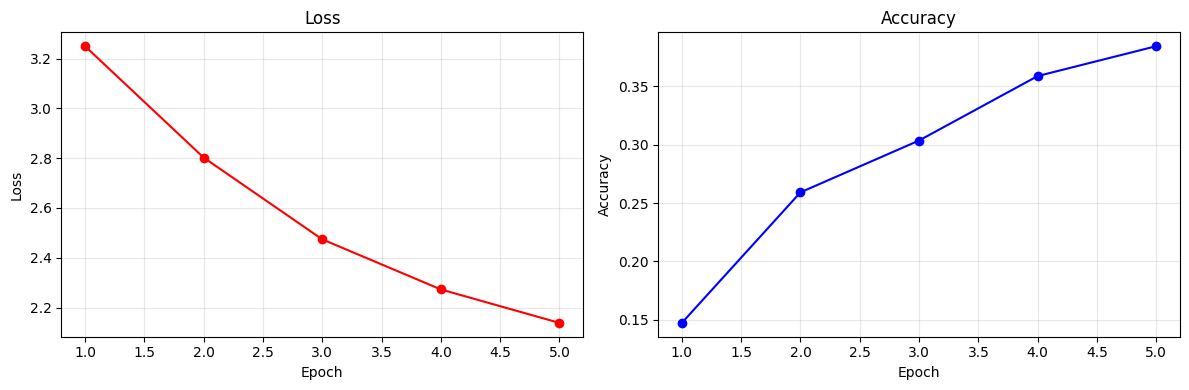

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.3748 - loss: 2.1939

 Temperature = 0.2
nt in cour tour and sour the and tour the are and uneres and in the are and the renend toully the and ind our and tour here and and and our well and heally our and and and one the dour sour and ind the and an the and tour and unelly and and tou there and our ane the pareses and tour sour sore and sour the gore and in the berend an mare here and and the pares tour the and and the parend tour and the parend and our and the pare and and there the mare the pares tour and andenst the paress tour oner

 Temperature = 0.5
se.

Arst Citizen:
I more hearsyores andineren tithenes ally an mishenss tou undes healf and is the bead memer to the reall, dou four and in mares tou sour four you ceall the wanst, ant one dith one meale you the hethinst andems anerens the cores our wis there cored une there thene entines sou thengoner; wores.
Wour ane fore fore and uner soud at one und oud mithe art hele so der

In [1]:
# ==============================
# Week 12 : Many-to-One Text Generation
# Character-level LSTM (Shakespeare)
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tensorflow.keras.callbacks import Callback

tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN = 30
EMBED_DIM = 64
EPOCHS = 5
BATCH = 32
NUM_SAMPLES = 5000
MAX_TOKENS = 10000

# ==============================
# 1. Load & Preprocess
# ==============================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path, 'r').read()[:MAX_TOKENS]
print(f"Text length: {len(text):,} chars")
print(f"First 200 chars:\n{text[:200]}\n")

chars = sorted(set(text))
VOCAB_SIZE = len(chars)
print(f"Unique chars: {VOCAB_SIZE}")

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded = np.array([char_to_idx[c] for c in text])

# --- Sliding Window ---
X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+SEQ_LEN])

X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])
print(f"Sequences: {X.shape},  Labels: {y.shape}")

# ==============================
# 2. Model
# ==============================
class LivePlot(Callback):
    def on_train_begin(self, logs=None):
        self.h = {k: [] for k in ['loss','accuracy']}
    def on_epoch_end(self, epoch, logs=None):
        for k in self.h: self.h[k].append(logs[k])
        ep = range(1, epoch + 2)
        clear_output(wait=True)
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
        a1.plot(ep, self.h['loss'], 'r-o')
        a1.set(title='Loss', xlabel='Epoch', ylabel='Loss'); a1.grid(True, alpha=.3)
        a2.plot(ep, self.h['accuracy'], 'b-o')
        a2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); a2.grid(True, alpha=.3)
        fig.tight_layout(); display(fig); plt.close(fig)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=EPOCHS, batch_size=BATCH, callbacks=[LivePlot()])
model.summary()
# ==============================
# 3. Text Generation
# ==============================
def generate(model, seed_text, length=500, temperature=1.0):
    result = list(seed_text)
    input_seq = [char_to_idx[c] for c in seed_text[-SEQ_LEN:]]
    for _ in range(length):
        x = np.array([input_seq[-SEQ_LEN:]])
        preds = model.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result)

# --- Temperature Comparison ---
seed = text[:SEQ_LEN]
temperatures = [0.2, 0.5, 1.0, 1.5]

for t in temperatures:
    print(f"\n{'='*60}")
    print(f" Temperature = {t}")
    print(f"{'='*60}")
    output = generate(model, seed, length=500, temperature=t)
    print(output[SEQ_LEN:])

# --- Long Generation (1000 chars) ---
print(f"\n{'='*60}")
print(f" Long Generation (1000 chars, temperature=0.5)")
print(f"{'='*60}")
long_output = generate(model, seed, length=1000, temperature=0.5)
print(long_output[SEQ_LEN:])